In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
import os
print(os.listdir())

['.config', 'sample_data']


In [24]:
df = pd.read_csv('/customer_shopping_behavior.csv')
df.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases,Return Status.1
0,TXN507808,CUST102534,01/01/2023,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,0,Same Day,1,Yes,Cash on Delivery,4,Return Status,0,Fortnightly,Return Status
1,TXN503830,CUST101256,01/01/2023,27,Female,Mumbai,Offline,NaN,Clothing,Shirt,...,0,NaN,0,No,UPI,5,Return Status,0,Fortnightly,Return Status
2,TXN501496,CUST100490,01/01/2023,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,0,Standard,7,Yes,UPI,3,Return Status,0,Rarely,Return Status
3,TXN501538,CUST100500,01/01/2023,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,0,Standard,6,Yes,Net Banking,4,Return Status,0,Fortnightly,Return Status
4,TXN504265,CUST101399,01/01/2023,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,99,Express,2,No,Debit Card,4,Return Status,0,Weekly,Return Status


In [25]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 27)


In [26]:
# Display column names
print(df.columns.tolist())

['Transaction ID', 'Customer ID', 'Purchase Date', 'Age', 'Gender', 'Location', 'Online/Offline', 'Online Store', 'Category', 'Item Purchased', 'Brand', 'Color', 'Size', 'Quantity', 'Purchase Amount (₹)', 'Discount (%)', 'Festival/Sale', 'Shipping Charge (₹)', 'Delivery Speed', 'Delivery Time (Days)', 'Subscription Status', 'Payment Method', 'Review Rating', 'Return Status', 'Previous Purchases', 'Frequency of Purchases', 'Return Status.1']


In [27]:
print(df.dtypes)

Transaction ID             object
Customer ID                object
Purchase Date              object
Age                         int64
Gender                     object
Location                   object
Online/Offline             object
Online Store               object
Category                   object
Item Purchased             object
Brand                      object
Color                      object
Size                       object
Quantity                    int64
Purchase Amount (₹)       float64
Discount (%)                int64
Festival/Sale              object
Shipping Charge (₹)         int64
Delivery Speed             object
Delivery Time (Days)        int64
Subscription Status        object
Payment Method             object
Review Rating               int64
Return Status              object
Previous Purchases          int64
Frequency of Purchases     object
Return Status.1            object
dtype: object


In [28]:
# Check missing values
print(df.isnull().sum())

Transaction ID               0
Customer ID                  0
Purchase Date                0
Age                          0
Gender                       0
Location                     0
Online/Offline               0
Online Store              2249
Category                     0
Item Purchased               0
Brand                        0
Color                        0
Size                      1035
Quantity                     0
Purchase Amount (₹)          2
Discount (%)                 0
Festival/Sale             6788
Shipping Charge (₹)          0
Delivery Speed            2249
Delivery Time (Days)         0
Subscription Status          0
Payment Method               0
Review Rating                0
Return Status                0
Previous Purchases           0
Frequency of Purchases       0
Return Status.1              0
dtype: int64


In [29]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [30]:
# Make a copy of the original dataset
df_clean = df.copy()


In [31]:

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

In [36]:
# Check for duplicate column names
print("Duplicate columns:")
print(df_clean.columns[df_clean.columns.duplicated()].tolist())

Duplicate columns:
[]


In [35]:
# Convert Purchase Date to datetime format
df_clean['Purchase Date'] = pd.to_datetime(
    df_clean['Purchase Date'],

)

# Fill missing numerical values with the median
numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with the mode
categorical_cols = df_clean.select_dtypes(include='object').columns

for col in categorical_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])



In [50]:
# Check the cleaned dataset
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

df_clean.head()

Original shape: (10000, 27)
Cleaned shape: (10000, 27)

Remaining missing values:
5884

Duplicate rows after cleaning:
0


,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases,Return Status.1
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,0,Same Day,1,Yes,Cash on Delivery,4,Return Status,0,Fortnightly,Return Status
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,Myntra,Clothing,Shirt,...,0,Standard,0,No,UPI,5,Return Status,0,Fortnightly,Return Status
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,0,Standard,7,Yes,UPI,3,Return Status,0,Rarely,Return Status
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,0,Standard,6,Yes,Net Banking,4,Return Status,0,Fortnightly,Return Status
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,99,Express,2,No,Debit Card,4,Return Status,0,Weekly,Return Status


In [49]:
# Descriptive statistics
print("Statistical Summary:")
display(df_clean[numeric_cols].describe())

Statistical Summary:


,Age,Quantity,Purchase Amount (₹),Discount (%),Shipping Charge (₹),Delivery Time (Days),Review Rating,Previous Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,38.278100,1.425100,1889.425500,32.916300,41.49210,3.703600,3.874900,3.211400
std,12.133041,0.761346,2102.158415,21.440617,64.30923,2.726223,0.912871,3.951313
min,18.000000,1.000000,67.000000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,28.000000,1.000000,600.000000,12.000000,0.00000,1.000000,3.000000,0.000000
50%,38.000000,1.000000,1206.500000,33.000000,0.00000,4.000000,4.000000,2.000000
75%,49.000000,2.000000,2376.000000,52.000000,79.00000,6.000000,5.000000,4.000000
max,59.000000,4.000000,22306.000000,70.000000,199.00000,8.000000,5.000000,28.000000


In [48]:
# Mean
print("\nMean:")
display(df_clean[numeric_cols].mean())


Mean:


,0
Age,38.2781
Quantity,1.4251
Purchase Amount (₹),1889.4255
Discount (%),32.9163
Shipping Charge (₹),41.4921
Delivery Time (Days),3.7036
Review Rating,3.8749
Previous Purchases,3.2114


In [46]:
# Median
print("\nMedian:")
display(df_clean[numeric_cols].median())



Median:


,0
Age,38.0
Quantity,1.0
Purchase Amount (₹),1206.5
Discount (%),33.0
Shipping Charge (₹),0.0
Delivery Time (Days),4.0
Review Rating,4.0
Previous Purchases,2.0


In [45]:
# Standard Deviation
print("\nStandard Deviation:")
display(df_clean[numeric_cols].std())



Standard Deviation:


,0
Age,12.133041
Quantity,0.761346
Purchase Amount (₹),2102.158415
Discount (%),21.440617
Shipping Charge (₹),64.309230
Delivery Time (Days),2.726223
Review Rating,0.912871
Previous Purchases,3.951313


In [43]:
# Correlation with Purchase Amount

target = 'Purchase Amount (₹)'

correlation = df_clean[numeric_cols].corr()

print("\nCorrelation with Purchase Amount:")
display(correlation[target].sort_values(ascending=False))


Correlation with Purchase Amount:


,Purchase Amount (₹)
Purchase Amount (₹),1.000000
Quantity,0.504102
Discount (%),0.164652
Previous Purchases,0.006784
Review Rating,0.005266
Delivery Time (Days),-0.008302
Age,-0.012111
Shipping Charge (₹),-0.088089


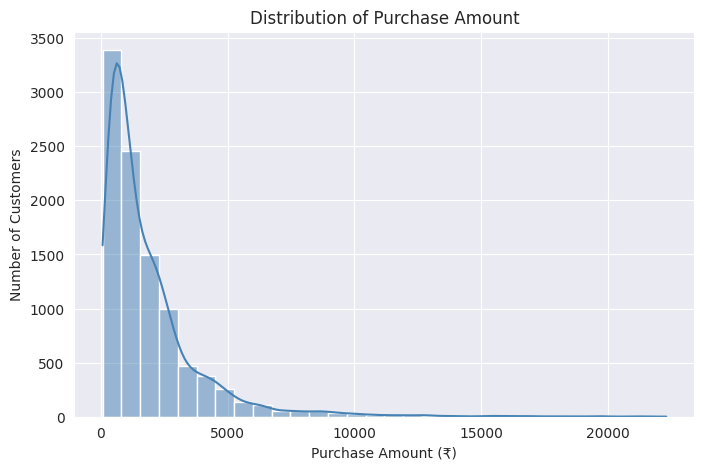

In [53]:
# Set visualization style
sns.set_style("darkgrid")

# Create figure
plt.figure(figsize=(8, 5))

# Histogram of Purchase Amount
sns.histplot(
    df_clean['Purchase Amount (₹)'],
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (₹)')
plt.ylabel('Number of Customers')
plt.show()

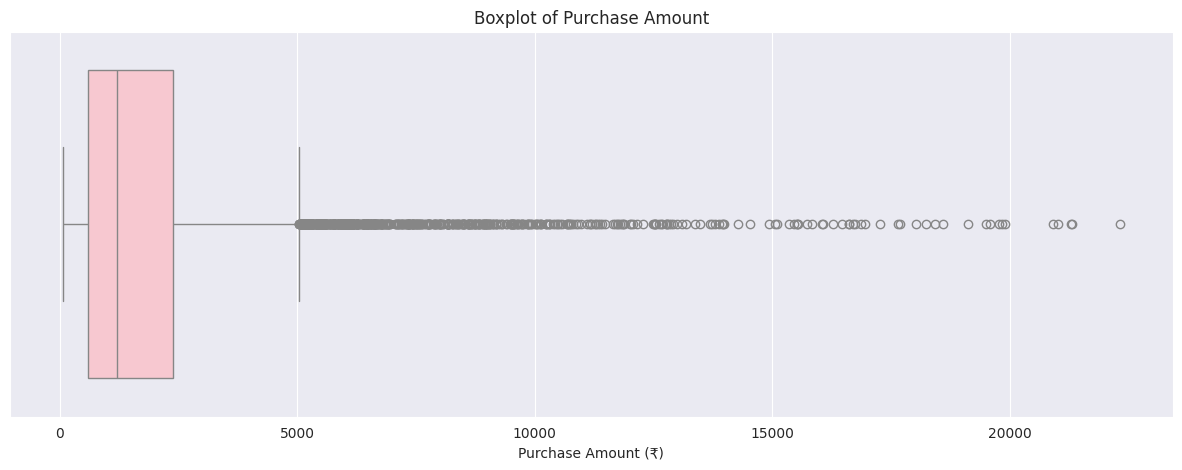

In [71]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    x=df_clean['Purchase Amount (₹)'],
    color='pink'
)

plt.title('Boxplot of Purchase Amount')
plt.xlabel('Purchase Amount (₹)')
plt.show()

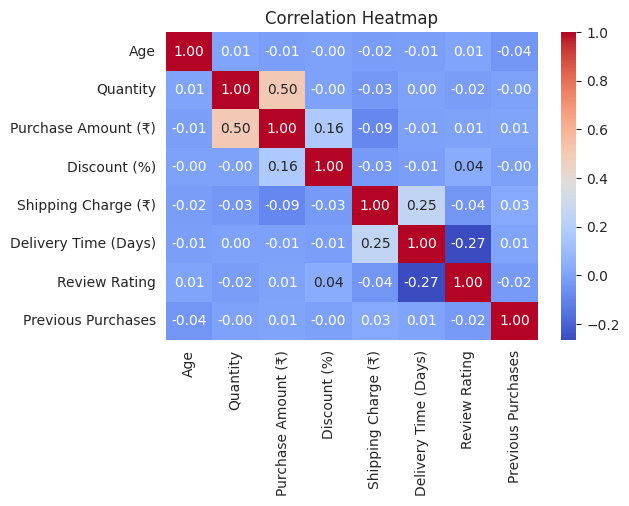

In [69]:
plt.figure(figsize=(6, 4))

correlation_matrix = df_clean[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# Target variable
target = 'Purchase Amount (₹)'

# Create X and y
X = df_clean.drop(columns=[target, 'Transaction ID', 'Customer ID']).copy()
y = df_clean[target]

# Convert Purchase Date into useful numerical features
X['Purchase Year'] = X['Purchase Date'].dt.year
X['Purchase Month'] = X['Purchase Date'].dt.month
X['Purchase Day'] = X['Purchase Date'].dt.day

# Remove original date column
X = X.drop(columns=['Purchase Date'])

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Create model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model training completed successfully!")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Model training completed successfully!
Training records: 8000
Testing records: 2000

First 10 Predictions:
[1015.85 2358.04  424.84 1189.21  845.56 2114.51 1341.46 2053.22 2340.27
 2459.37]


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION")
print("----------------------------")
print(f"Mean Absolute Error (MAE): ₹{mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MODEL EVALUATION
----------------------------
Mean Absolute Error (MAE): ₹599.64
Root Mean Squared Error (RMSE): ₹1139.77
R² Score: 0.6945


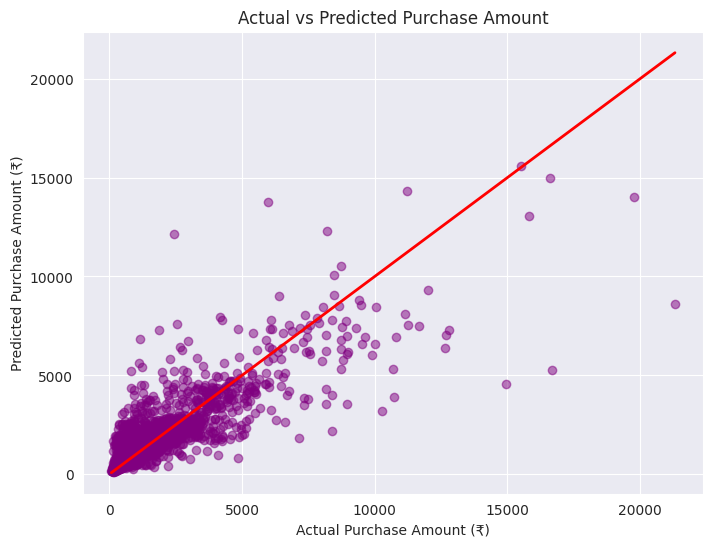

In [75]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5, color='purple')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel('Actual Purchase Amount (₹)')
plt.ylabel('Predicted Purchase Amount (₹)')
plt.title('Actual vs Predicted Purchase Amount')
plt.show()